<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Housing Dataset generated successfully!
Dataset Shape: (2000, 8)
   SquareFeet  Bedrooms  Bathrooms  PropertyAge  LocationScore  \
0      2398.0         3        2.0           17            3.0   
1      2017.0         1        2.5            9            1.5   
2      2489.0         2        3.0           27            1.9   
3      3014.0         2        1.0           10            4.9   
4      1960.0         4        1.5           32            3.1   

   DistanceToCity_KM  HasGarage   Price  
0                4.8          1  539.53  
1               29.2          1  344.87  
2                9.6          0  441.74  
3               27.4          0  583.28  
4               33.5          0  345.01  


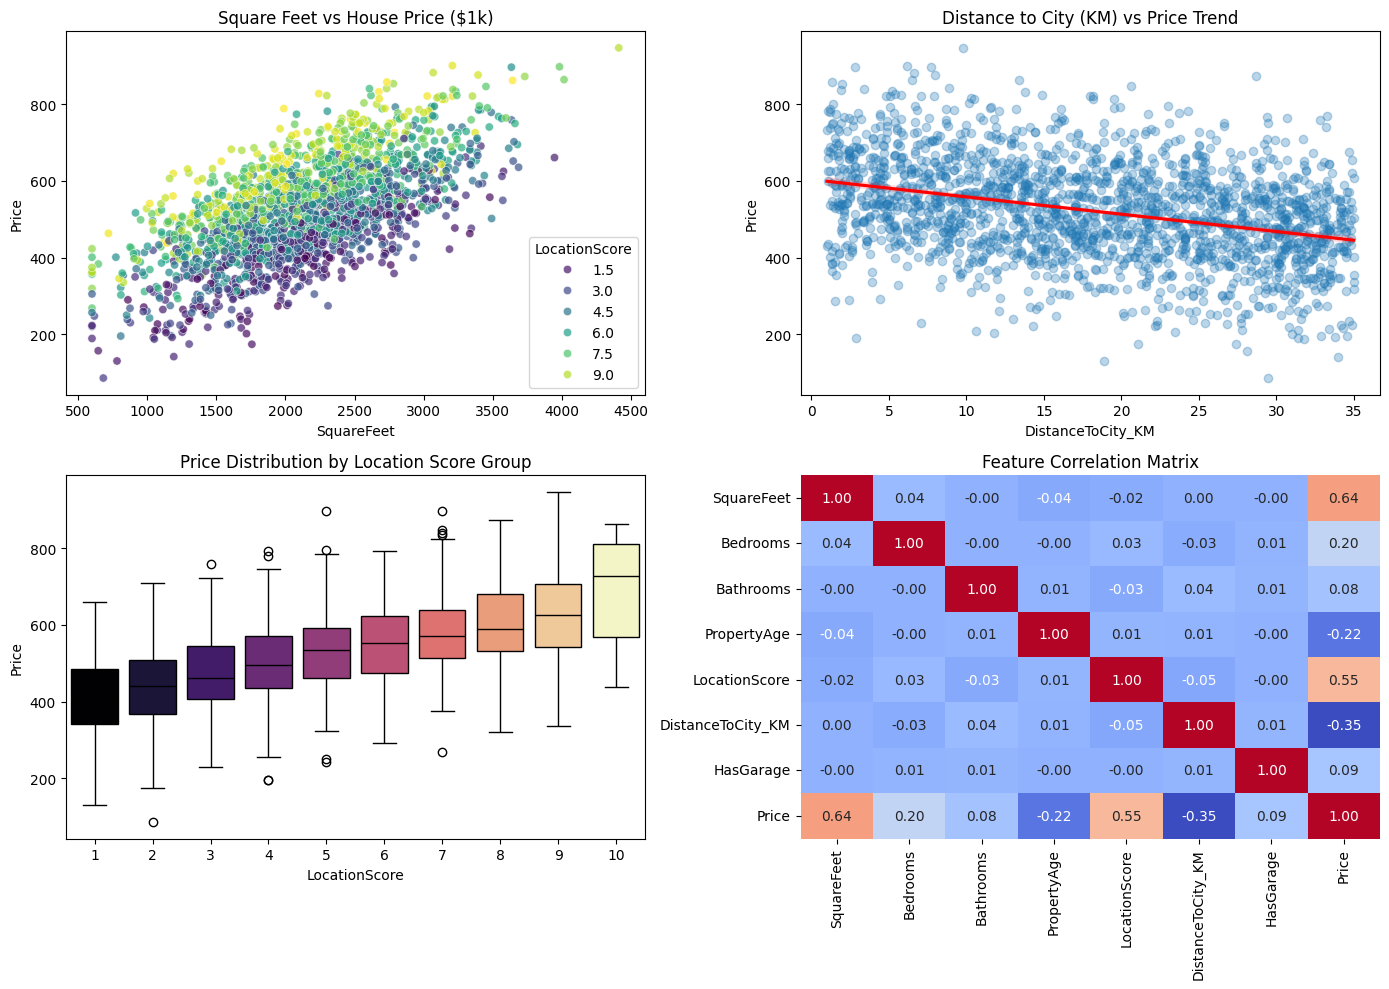

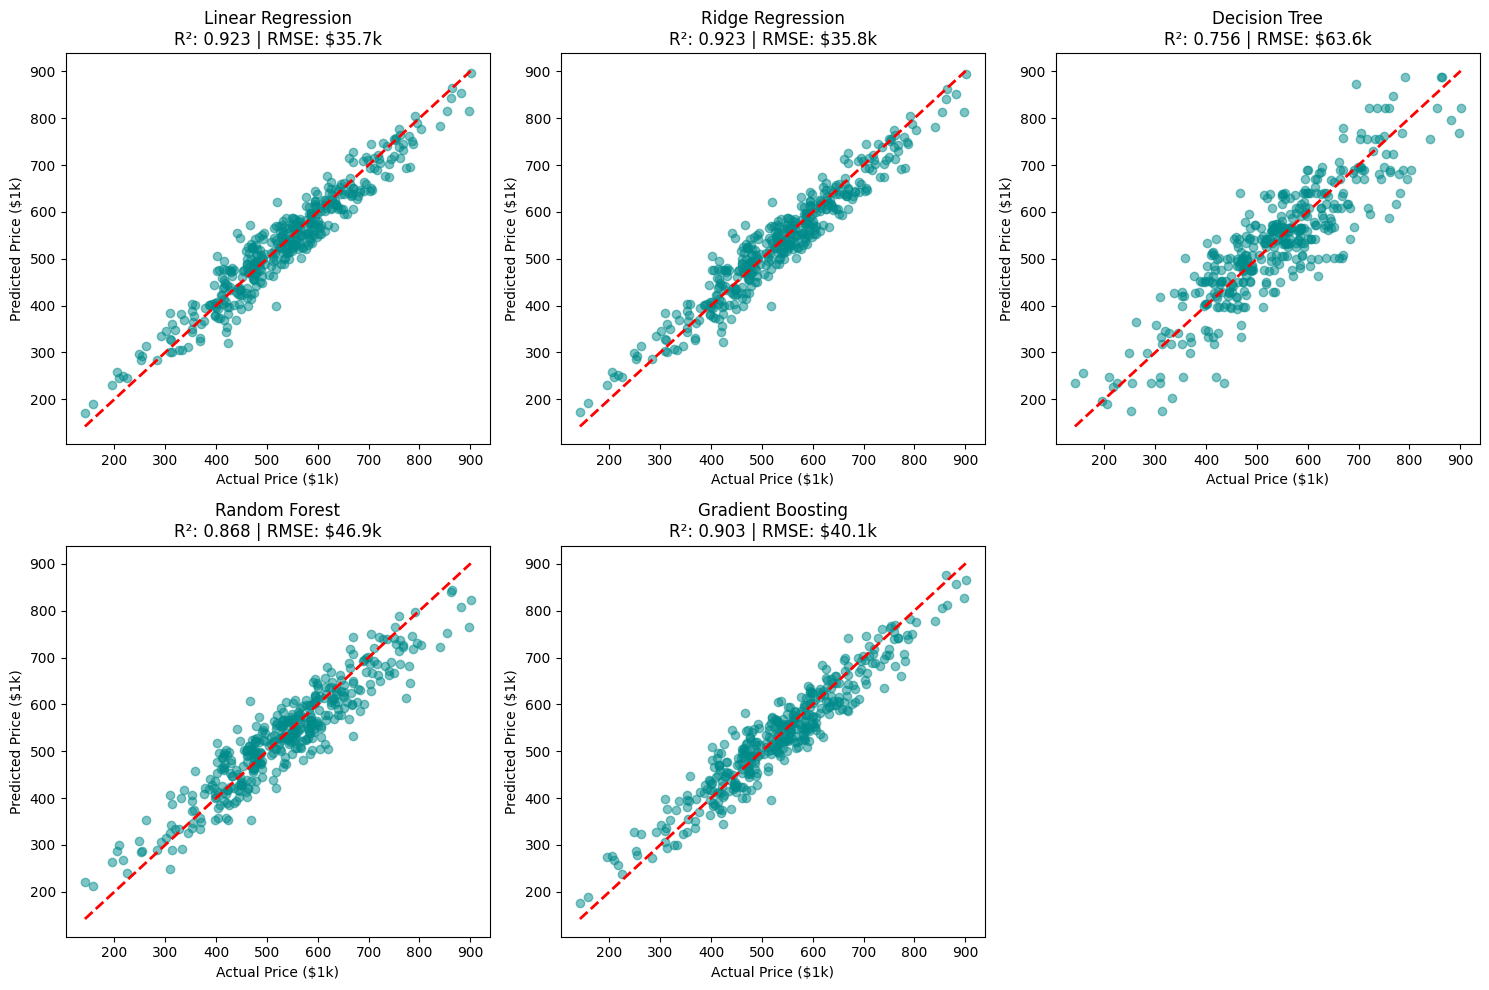

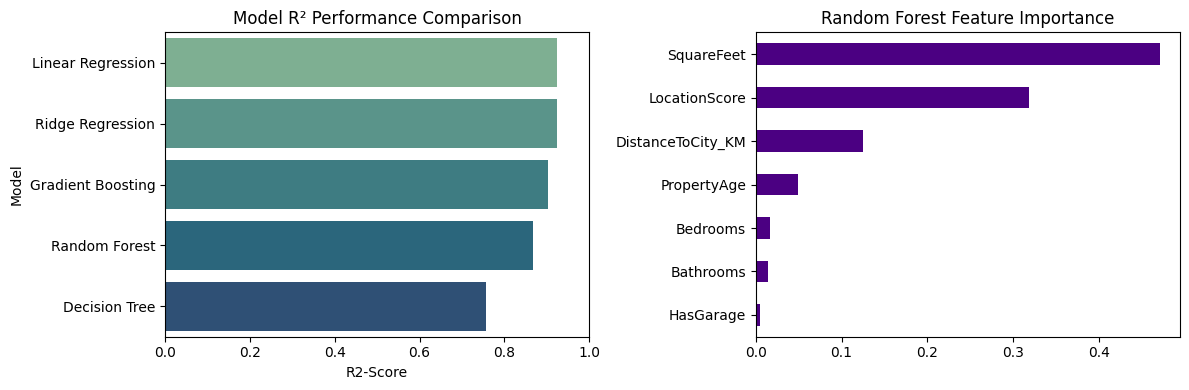


=== HOUSE PRICE PREDICTION PERFORMANCE RANKING ===
            Model  R2-Score  MAE ($1k)  RMSE ($1k)
Linear Regression  0.923332  28.604713   35.685045
 Ridge Regression  0.923014  28.652916   35.758891
Gradient Boosting  0.903163  32.416937   40.105054
    Random Forest  0.867750  37.407536   46.867994
    Decision Tree  0.756371  49.983680   63.612577


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.simplefilter(action='ignore', category=FutureWarning)

# ==========================================
# 1. GENERATE REALISTIC HOUSING DATASET
# ==========================================
np.random.seed(42)
n_samples = 2000

square_feet = np.random.normal(2100, 600, n_samples).clip(600, 5000).round(0)
bedrooms = np.random.choice([1, 2, 3, 4, 5], size=n_samples, p=[0.1, 0.25, 0.4, 0.2, 0.05])
bathrooms = np.random.choice([1.0, 1.5, 2.0, 2.5, 3.0, 3.5], size=n_samples, p=[0.15, 0.2, 0.35, 0.15, 0.1, 0.05])
property_age = np.random.randint(0, 50, n_samples)
location_score = np.random.uniform(1, 10, n_samples).round(1)  # 1 (poor) to 10 (prime)
distance_to_city_km = np.random.uniform(1, 35, n_samples).round(1)
has_garage = np.random.choice([0, 1], size=n_samples, p=[0.3, 0.7])

# Price target (in $1000s) computed with real estate pricing domain logic + non-linear terms & noise
price = (
    80.0
    + 0.14 * square_feet
    + 18.0 * bedrooms
    + 22.0 * bathrooms
    - 1.8 * property_age
    + 28.0 * location_score
    - 4.2 * distance_to_city_km
    + 25.0 * has_garage
    + np.random.normal(0, 35, n_samples)
).round(2)

df = pd.DataFrame({
    'SquareFeet': square_feet,
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'PropertyAge': property_age,
    'LocationScore': location_score,
    'DistanceToCity_KM': distance_to_city_km,
    'HasGarage': has_garage,
    'Price': price
})

print("Housing Dataset generated successfully!")
print(f"Dataset Shape: {df.shape}")
print(df.head())


# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(14, 10))

# Graph 1: Square Footage vs Price
plt.subplot(2, 2, 1)
sns.scatterplot(x="SquareFeet", y="Price", data=df, hue="LocationScore", palette="viridis", alpha=0.7)
plt.title("Square Feet vs House Price ($1k)")

# Graph 2: Distance to City Center vs Price
plt.subplot(2, 2, 2)
sns.regplot(x="DistanceToCity_KM", y="Price", data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Distance to City (KM) vs Price Trend")

# Graph 3: Location Quality Score vs Price
plt.subplot(2, 2, 3)
sns.boxplot(x=np.floor(df["LocationScore"]).astype(int), y=df["Price"], hue=np.floor(df["LocationScore"]).astype(int), palette="magma", legend=False)
plt.title("Price Distribution by Location Score Group")

# Graph 4: Feature Correlation Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()


# ==========================================
# 3. PREPROCESSING & SPLITTING
# ==========================================
X = df.drop(columns=["Price"])
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 4. MODEL TRAINING & REGRESSION EVALUATION
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=8),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2-Score": r2,
        "MAE ($1k)": mae,
        "RMSE ($1k)": rmse
    })

    # Plot Actual vs Predicted Prices
    axes[idx].scatter(y_test, y_pred, alpha=0.5, color='darkcyan')
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_title(f"{name}\nR²: {r2:.3f} | RMSE: ${rmse:.1f}k")
    axes[idx].set_xlabel("Actual Price ($1k)")
    axes[idx].set_ylabel("Predicted Price ($1k)")

axes[5].axis("off")
plt.tight_layout()
plt.show()


# ==========================================
# 5. MODEL RANKING & FEATURE IMPORTANCE
# ==========================================
results_df = pd.DataFrame(results).sort_values(by="R2-Score", ascending=False)

plt.figure(figsize=(12, 4))

# Chart 1: R2-Score Comparison
plt.subplot(1, 2, 1)
sns.barplot(x="R2-Score", y="Model", data=results_df, hue="Model", palette="crest", legend=False)
plt.title("Model R² Performance Comparison")
plt.xlim(0, 1)

# Chart 2: Feature Importance from Random Forest
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.subplot(1, 2, 2)
importances.plot(kind="barh", color="indigo")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

print("\n=== HOUSE PRICE PREDICTION PERFORMANCE RANKING ===")
print(results_df.to_string(index=False))